# 1D Helmholtz Solver — EM Reflection & Transmission at a Dielectric Transition Layer

Solves the reduced 1D Helmholtz equation on the z-axis for a plane wave incident at angle $\theta$ from a uniform medium $\varepsilon_1$ through a transition layer $[z_1, z_2]$ with profile $\varepsilon_r(z)$ into a second uniform medium $\varepsilon_2$.

**TE (S-polarisation):**
$$\frac{d^2 E_y}{dz^2} + \bigl[k_0^2\,\varepsilon_r(z) - k_x^2\bigr]\,E_y = 0$$

**TM (P-polarisation):**
$$\frac{d^2 H_y}{dz^2} - \frac{1}{\varepsilon_r}\frac{d\varepsilon_r}{dz}\frac{dH_y}{dz} + \bigl[k_0^2\,\varepsilon_r(z) - k_x^2\bigr]\,H_y = 0$$

with $k_x = k_0\sqrt{\varepsilon_1}\sin\theta$ conserved (Snell's law).

Two independent numerical methods:
- **Method 1 — ODE shooting** (diffrax `Dopri5`, adaptive step, backward integration $z_2 \to z_1$)
- **Method 2 — FEM** (linear elements, non-uniform mesh, Robin port BCs, `scipy.sparse.linalg.spsolve`)

In [4]:
import jax
jax.config.update('jax_enable_x64', True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print('Using GPU:', jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print('GPU not available, using CPU.', flush=True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from main import (
    HelmholtzSolver1D, make_kz, extract_rt,
    build_interp_arrays, sweep_ode, sweep_fem,
)

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]


## Test 1 — Normal Incidence, Linear $\varepsilon$ Profile

Simplest case: $\theta = 0$, so $k_x = 0$ and TE $\equiv$ TM.  
Linear profile: $\varepsilon_r(z) = \varepsilon_1 + (\varepsilon_2 - \varepsilon_1)\,(z - z_1)/(z_2 - z_1)$ over $[z_1, z_2]$.  
Both ODE and FEM results are plotted together for cross-validation.

In [5]:
lambda0 = 1.0
z1, z2  = -0.5, 0.5     # transition layer of width 1 λ₀
eps1, eps2 = 1.0, 4.0   # air → glass (n=2)

def eps_linear(z):
    if z <= z1: return eps1
    if z >= z2: return eps2
    return eps1 + (eps2 - eps1) * (z - z1) / (z2 - z1)

solver1 = HelmholtzSolver1D(eps_linear, z1, z2, theta_deg=0.0, pol='S', lambda0=lambda0)

HelmholtzSolver1D: pol=S, θ=0.0°, λ₀=1.0, ε₁=1+0j, ε₂=4+0j, kz1=6.283+0j, kz2=12.57+0j


In [6]:
res1_ode  = solver1.solve_ode()
res1_fem1 = solver1.solve_fem(order=1)   # P1 linear
res1_fem2 = solver1.solve_fem(order=2)   # P2 quadratic

for label, res in [('ODE', res1_ode), ('FEM P1', res1_fem1), ('FEM P2', res1_fem2)]:
    RT = solver1.energy_check(res['r'], res['t'])
    print(f"{label:8s}: |r|²={abs(res['r'])**2:.5f}  R+T={RT:.6f}")

  → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Dopri5] r = 0.0495∠112.9°, t = 0.7062∠160.4°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.0515∠112.1°, t = 0.7062∠160.6°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.0495∠112.9°, t = 0.7062∠160.4°
Energy check: R=0.002455, T=0.997545, R+T=1.000000
ODE     : |r|²=0.00245  R+T=1.000000
Energy check: R=0.002651, T=0.997542, R+T=1.000193
FEM P1  : |r|²=0.00265  R+T=1.000193
Energy check: R=0.002454, T=0.997546, R+T=1.000000
FEM P2  : |r|²=0.00245  R+T=1.000000


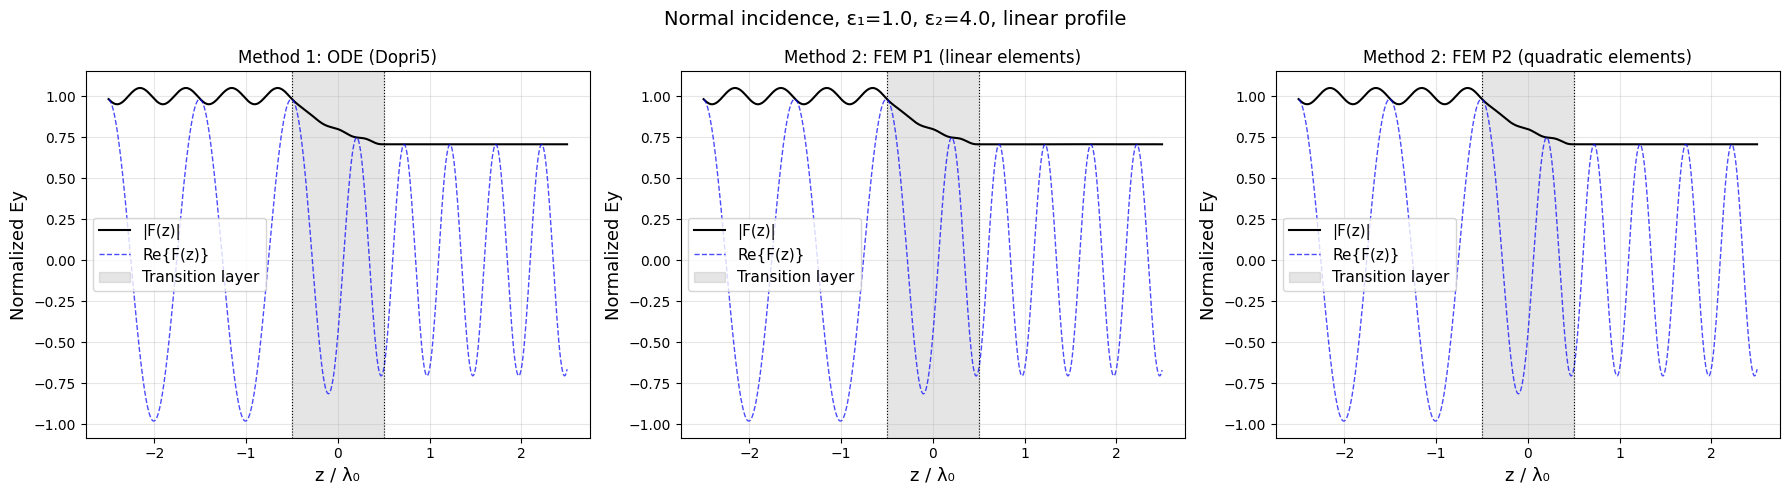

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Normal incidence, ε₁={eps1}, ε₂={eps2}, linear profile', fontsize=14)
solver1.plot_field(res1_ode,  ax=axes[0], title='Method 1: ODE (Dopri5)')
solver1.plot_field(res1_fem1, ax=axes[1], title='Method 2: FEM P1 (linear elements)')
solver1.plot_field(res1_fem2, ax=axes[2], title='Method 2: FEM P2 (quadratic elements)')
plt.tight_layout()
plt.savefig('test1_fields.png', dpi=120)
plt.show()

## Test 2 — Oblique Incidence: TE vs TM

At oblique incidence ($\theta = 45°$), TE and TM polarisations give different reflection/transmission coefficients (Fresnel effect).  
The TM equation has an extra drift term $(1/\varepsilon)\,(d\varepsilon/dz)\,(dH_y/dz)$ that weakens the effective refractive index mismatch, leading to lower $|r|$ — this is the origin of Brewster's angle.

We use the same linear profile as Test 1.

In [5]:
theta = 45.0
solver_te = HelmholtzSolver1D(eps_linear, z1, z2, theta_deg=theta, pol='S', lambda0=lambda0)
solver_tm = HelmholtzSolver1D(eps_linear, z1, z2, theta_deg=theta, pol='P', lambda0=lambda0)

res_te_ode  = solver_te.solve_ode()
res_te_fem1 = solver_te.solve_fem(order=1)
res_te_fem2 = solver_te.solve_fem(order=2)
res_tm_ode  = solver_tm.solve_ode()
res_tm_fem1 = solver_tm.solve_fem(order=1)
res_tm_fem2 = solver_tm.solve_fem(order=2)

for label, res in [('TE ODE', res_te_ode),  ('TE FEM P1', res_te_fem1), ('TE FEM P2', res_te_fem2),
                   ('TM ODE', res_tm_ode),  ('TM FEM P1', res_tm_fem1), ('TM FEM P2', res_tm_fem2)]:
    r, t = res['r'], res['t']
    sv = solver_te if 'TE' in label else solver_tm
    RT = sv.energy_check(r, t)
    print(f"{label:12s}: |r|={abs(r):.4f}  |t|={abs(t):.4f}  R+T={RT:.6f}")

HelmholtzSolver1D: pol=S, θ=45.0°, λ₀=1.0, ε₁=1+0j, ε₂=4+0j, kz1=4.443+0j, kz2=11.75+0j
HelmholtzSolver1D: pol=P, θ=45.0°, λ₀=1.0, ε₁=1+0j, ε₂=4+0j, kz1=4.443+0j, kz2=11.75+0j
  → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Dopri5] r = 0.1161∠115.5°, t = 0.6106∠-134.3°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.1172∠115.4°, t = 0.6110∠-134.2°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.1161∠115.6°, t = 0.6106∠-134.3°
  → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Dopri5] r = 0.0243∠-124.1°, t = 1.2292∠-135.4°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.0233∠-125.8°, t = 1.2299∠-135.3°
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.0243∠-124.1°, t = 1.2292∠-135.4°
Energy check: R=0.013474, T=0.986526, R+T=1.000000
TE ODE      : |r|=0.1161  |t|=0.6106  R+T=1.000000
Energy check: R=0.013734, T=0.987559, R+T=1.001292
TE FEM P1 

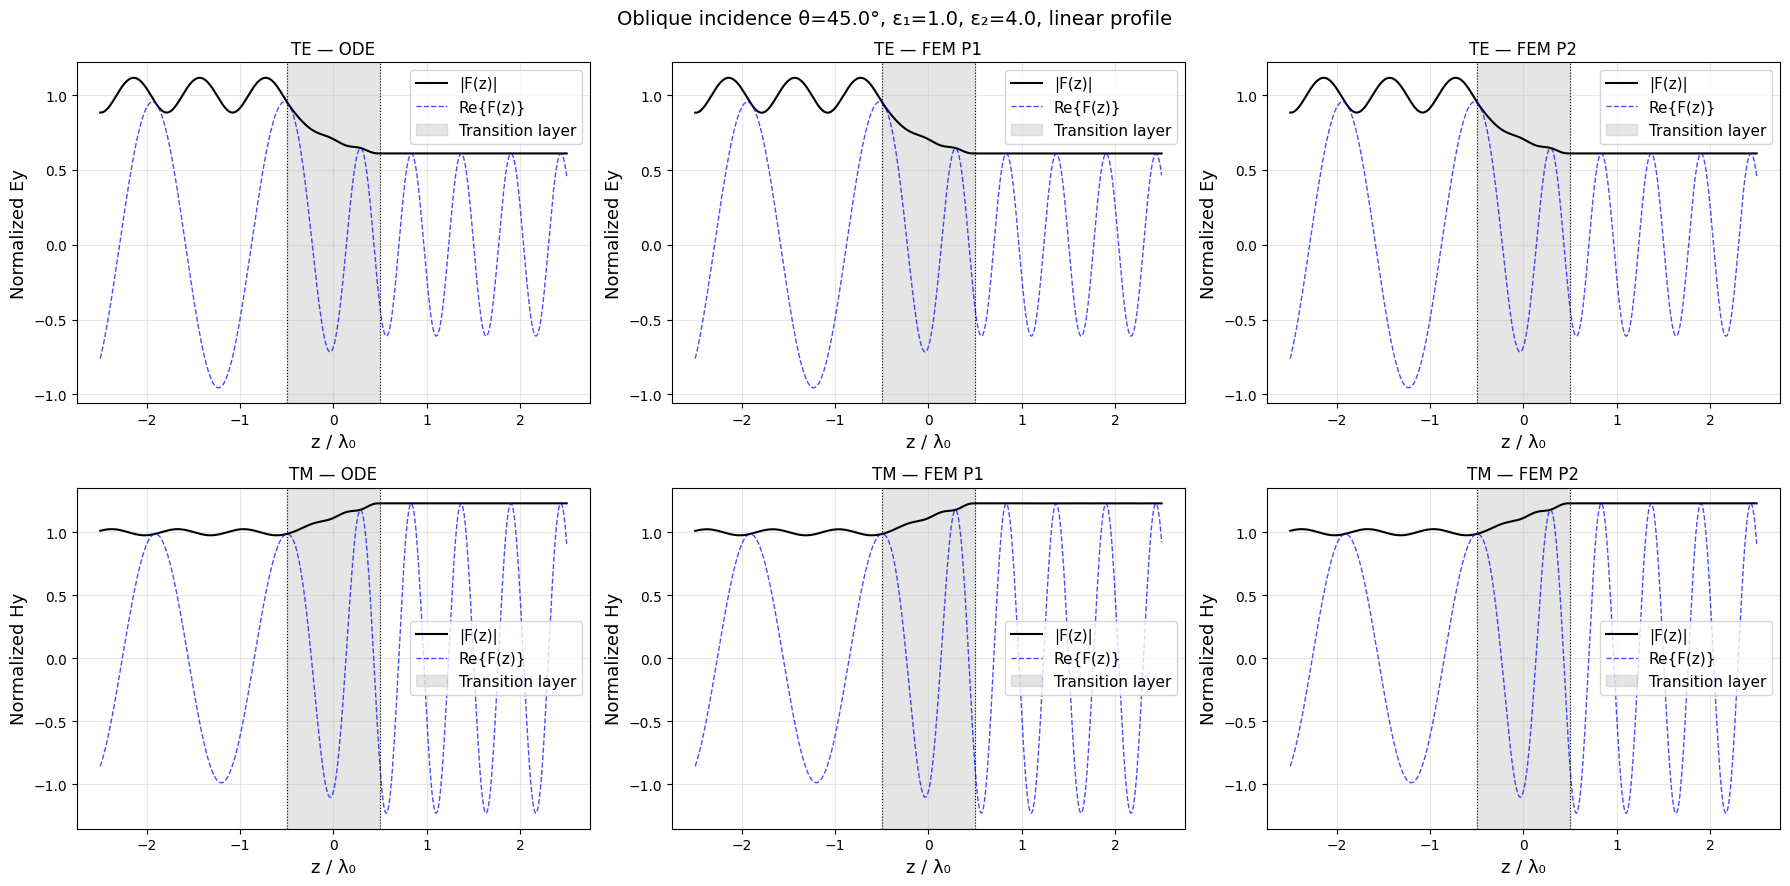

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f'Oblique incidence θ={theta}°, ε₁={eps1}, ε₂={eps2}, linear profile', fontsize=14)
solver_te.plot_field(res_te_ode,  ax=axes[0, 0], title='TE — ODE')
solver_te.plot_field(res_te_fem1, ax=axes[0, 1], title='TE — FEM P1')
solver_te.plot_field(res_te_fem2, ax=axes[0, 2], title='TE — FEM P2')
solver_tm.plot_field(res_tm_ode,  ax=axes[1, 0], title='TM — ODE')
solver_tm.plot_field(res_tm_fem1, ax=axes[1, 1], title='TM — FEM P1')
solver_tm.plot_field(res_tm_fem2, ax=axes[1, 2], title='TM — FEM P2')
plt.tight_layout()
plt.savefig('test2_oblique.png', dpi=120)
plt.show()

## Test 3 — Reflectance $|r|^2$ vs Angle: Sharp Interface vs Linear Gradient

For a **sharp** ($d \to 0$) interface the exact Fresnel coefficients are:
$$r_\text{TE} = \frac{k_{z1} - k_{z2}}{k_{z1} + k_{z2}}, \qquad
r_\text{TM} = \frac{\varepsilon_2 k_{z1} - \varepsilon_1 k_{z2}}{\varepsilon_2 k_{z1} + \varepsilon_1 k_{z2}}$$

For a **smooth linear gradient** of width $d = z_2 - z_1$, the reflection is reduced because the impedance mismatch is spread over many wavelengths.  
Brewster's angle for the sharp interface: $\theta_B = \arctan\!\sqrt{\varepsilon_2/\varepsilon_1}$.

In [7]:
thetas = np.linspace(0, 85, 50)
k0 = 2 * np.pi / lambda0

# ── Fresnel (sharp interface) — vectorized numpy ───────────────────────────
kx_np  = k0 * np.sqrt(eps1) * np.sin(np.deg2rad(thetas))
kz1_np = np.array([make_kz(eps1, float(np.real(kx)), k0) for kx in kx_np])
kz2_np = np.array([make_kz(eps2, float(np.real(kx)), k0) for kx in kx_np])
R_te_fresnel = np.abs((kz1_np - kz2_np) / (kz1_np + kz2_np))**2
R_tm_fresnel = np.abs((eps2*kz1_np - eps1*kz2_np) / (eps2*kz1_np + eps1*kz2_np))**2

# ── Linear gradient (ODE, vmapped) ──────────────────────────────────────────
# res_trans default = 10 × max|ε| = 10×4 = 40/λ₀; width=1λ₀ → n_trans=40
_res_sweep = 10.0 * eps2   # = 40
_n_trans_sweep = max(10, int(np.ceil(_res_sweep * (z2 - z1) / lambda0)))

N = len(thetas)
z_grid, eps_grid, deps_grid = build_interp_arrays(eps_linear, z1, z2, n=10000)
eps_re  = jnp.real(eps_grid);  eps_im  = jnp.imag(eps_grid)
deps_re = jnp.real(deps_grid); deps_im = jnp.imag(deps_grid)

kx_arr  = jnp.array(kx_np.real)
kz1_arr = jnp.array(kz1_np, dtype=jnp.complex128)
kz2_arr = jnp.array(kz2_np, dtype=jnp.complex128)

eps_re_arr  = jnp.tile(eps_re[None],  (N, 1))
eps_im_arr  = jnp.tile(eps_im[None],  (N, 1))
deps_re_arr = jnp.tile(deps_re[None], (N, 1))
deps_im_arr = jnp.tile(deps_im[None], (N, 1))

print(f"Angle sweep with res_trans={_res_sweep:.0f}/λ₀ → n_trans={_n_trans_sweep}")
print("Running vmapped TE sweep...", flush=True)
R_te_grad = np.array(sweep_ode(
    kx_arr, kz1_arr, kz2_arr,
    eps_re_arr, eps_im_arr, deps_re_arr, deps_im_arr,
    z_grid, float(k0), float(z1), float(z2), _n_trans_sweep, 'S',
))
print("Running vmapped TM sweep...", flush=True)
R_tm_grad = np.array(sweep_ode(
    kx_arr, kz1_arr, kz2_arr,
    eps_re_arr, eps_im_arr, deps_re_arr, deps_im_arr,
    z_grid, float(k0), float(z1), float(z2), _n_trans_sweep, 'P',
))

theta_B = np.degrees(np.arctan(np.sqrt(eps2 / eps1)))
print(f"Brewster angle (sharp interface): {theta_B:.2f}°")

Angle sweep with res_trans=40/λ₀ → n_trans=40
Running vmapped TE sweep...
Running vmapped TM sweep...
Brewster angle (sharp interface): 63.43°


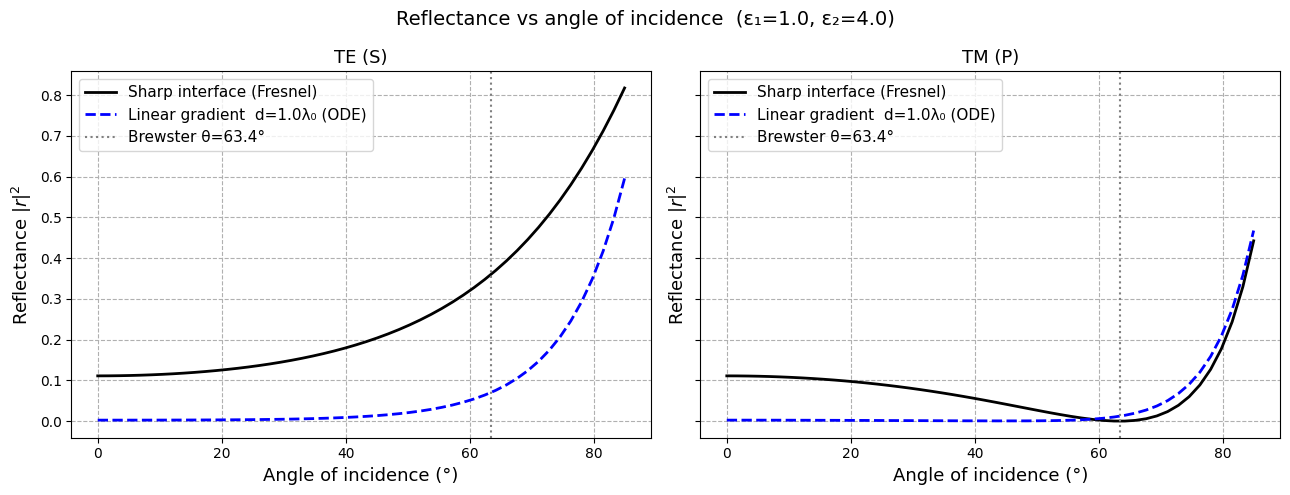

In [9]:
fig, (ax_te, ax_tm) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(f'Reflectance vs angle of incidence  (ε₁={eps1}, ε₂={eps2})', fontsize=14)

for ax, R_fresnel, R_grad, pol_label in [
        (ax_te, R_te_fresnel, R_te_grad, 'TE (S)'),
        (ax_tm, R_tm_fresnel, R_tm_grad, 'TM (P)'),
]:
    ax.plot(thetas, R_fresnel, 'k-',  lw=2.0, label='Sharp interface (Fresnel)')
    ax.plot(thetas, R_grad,   'b--', lw=2.0, label=f'Linear gradient  d={z2-z1:.1f}λ₀ (ODE)')
    ax.axvline(theta_B, color='gray', ls=':', lw=1.5, label=f'Brewster θ={theta_B:.1f}°')
    ax.set_xlabel('Angle of incidence (°)', fontsize=13)
    ax.set_ylabel('Reflectance $|r|^2$', fontsize=13)
    ax.set_title(pol_label, fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, ls='--')

plt.tight_layout()
plt.savefig('test3_R_vs_theta.png', dpi=120)
plt.show()

## Test 4 — Convergence vs Resolution (ODE & FEM P1 vs P2)

Take the ODE solution at $\mathrm{res\_trans}=8000/\lambda_0$ as reference and measure $|r_N - r_{\rm ref}|$.

**Root cause of FEM P1 non-convergence**: P1 linear elements have numerical dispersion
$k_h \approx k\bigl(1 - k^2h^2/24\bigr)$, giving dispersion error O(h²) per element.
The Robin (absorbing) BC uses the *exact* $k_{z2}$, but the FEM wave propagates at $k_h \neq k$.
This mismatch creates a small reflection at the boundary, producing standing-wave oscillations
in $|F(z)|$ for $z > z_2$.  Refining `res_trans` without equally refining `res_ext` leaves the
exterior dispersion error unchanged — that is why FEM P1 error plateaus.

**Fix**: P2 quadratic elements reduce dispersion to O(h⁴), eliminating the exterior oscillations
and restoring convergence at the same mesh density.

Expected slopes: ODE ≈ 5 (Dopri5), FEM P1 ≈ 2 (both res_trans and res_ext swept equally), FEM P2 ≈ 4.

In [10]:
solver_ref = HelmholtzSolver1D(eps_linear, z1, z2, theta_deg=30.0, pol='S', lambda0=lambda0)
ref_ode = solver_ref.solve_ode(res_trans=8000, res_ext=300)
r_ref = ref_ode['r']

# Sweep: res_ext = res_trans / 2 so both interior and exterior converge together.
res_list = [5, 10, 20, 40, 80, 160, 320, 640]
err_ode, err_fem1, err_fem2 = [], [], []

for res in res_list:
    res_e = max(5, res // 2)
    ro  = solver_ref.solve_ode(res_trans=res, res_ext=res_e)
    rf1 = solver_ref.solve_fem(res_trans=res, res_ext=res_e, order=1)
    rf2 = solver_ref.solve_fem(res_trans=res, res_ext=res_e, order=2)
    err_ode.append(abs(ro['r'] - r_ref))
    err_fem1.append(abs(rf1['r'] - r_ref))
    err_fem2.append(abs(rf2['r'] - r_ref))
    print(f"res={res:4.0f}/λ₀: ODE={err_ode[-1]:.2e}  FEM-P1={err_fem1[-1]:.2e}  FEM-P2={err_fem2[-1]:.2e}")

HelmholtzSolver1D: pol=S, θ=30.0°, λ₀=1.0, ε₁=1+0j, ε₂=4+0j, kz1=5.441+0j, kz2=12.17+0j
  → ODE res_trans=8000.00/λ₀ → n_trans=8000
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
  → ODE res_trans=5.00/λ₀ → n_trans=10
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
  → FEM res_trans=5.00/λ₀ → n_trans=10,  res_ext=5.00/λ₀ → n_ext=10
[FEM] r = 0.7649∠95.2°, t = 0.8606∠-122.7°
  → FEM res_trans=5.00/λ₀ → n_trans=10,  res_ext=5.00/λ₀ → n_ext=10
[FEM] r = 0.1007∠139.7°, t = 0.6338∠-166.6°
res=   5/λ₀: ODE=7.58e-14  FEM-P1=6.99e-01  FEM-P2=5.26e-02
  → ODE res_trans=10.00/λ₀ → n_trans=10
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
  → FEM res_trans=10.00/λ₀ → n_trans=10,  res_ext=5.00/λ₀ → n_ext=10
[FEM] r = 0.7649∠95.2°, t = 0.8606∠-122.7°
  → FEM res_trans=10.00/λ₀ → n_trans=10,  res_ext=5.00/λ₀ → n_ext=10
[FEM] r = 0.1007∠139.7°, t = 0.6338∠-166.6°
res=  10/λ₀: ODE=7.58e-14  FEM-P1=6.99e-01  FEM-P2=5.26e-02
  → ODE res_trans=20.00/λ₀ → n_trans=20
[ODE/Dopri5] r = 0.0685∠110.

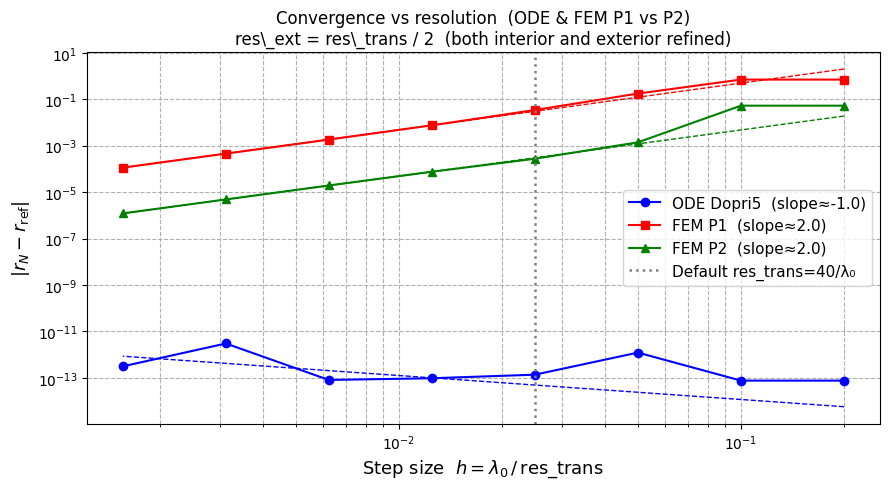

In [11]:
h_list      = lambda0 / np.array(res_list, dtype=float)
res_default = 10.0 * eps2

# Fit slopes over last 4 points (asymptotic regime)
ok1 = np.array(err_fem1) > 1e-14
ok2 = np.array(err_fem2) > 1e-14
coef_ode  = np.polyfit(np.log(h_list[-4:]),          np.log(err_ode[-4:]),           1)
coef_fem1 = np.polyfit(np.log(h_list[ok1][-4:]),     np.log(np.array(err_fem1)[ok1][-4:]), 1) if ok1.sum() >= 4 else [0, 0]
coef_fem2 = np.polyfit(np.log(h_list[ok2][-4:]),     np.log(np.array(err_fem2)[ok2][-4:]), 1) if ok2.sum() >= 4 else [0, 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(h_list, err_ode,  'bo-', ms=6, label=f'ODE Dopri5  (slope≈{coef_ode[0]:.1f})')
ax.loglog(h_list, err_fem1, 'rs-', ms=6, label=f'FEM P1  (slope≈{coef_fem1[0]:.1f})')
ax.loglog(h_list, err_fem2, 'g^-', ms=6, label=f'FEM P2  (slope≈{coef_fem2[0]:.1f})')
ax.loglog(h_list, np.exp(coef_ode[1])  * h_list**coef_ode[0],  'b--', lw=1)
ax.loglog(h_list, np.exp(coef_fem1[1]) * h_list**coef_fem1[0], 'r--', lw=1)
ax.loglog(h_list, np.exp(coef_fem2[1]) * h_list**coef_fem2[0], 'g--', lw=1)

ax.axvline(lambda0 / res_default, color='gray', ls=':', lw=1.8,
           label=f'Default res_trans={res_default:.0f}/λ₀')

ax.set_xlabel(r'Step size  $h = \lambda_0\,/\,\mathrm{res\_trans}$', fontsize=13)
ax.set_ylabel(r'$|r_N - r_{\mathrm{ref}}|$', fontsize=13)
ax.set_title('Convergence vs resolution  (ODE & FEM P1 vs P2)\n'
             r'res\_ext = res\_trans / 2  (both interior and exterior refined)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig('test4_convergence.png', dpi=120)
plt.show()

## Test 5 — Sharp Interface: Compare with Fresnel Formulas

As the transition width $d = z_2 - z_1 \to 0$, the smooth-profile solver should recover the exact Fresnel reflection coefficient:

$$r_\text{TE} = \frac{k_{z1} - k_{z2}}{k_{z1} + k_{z2}}, \qquad
r_\text{TM} = \frac{\varepsilon_2\,k_{z1} - \varepsilon_1\,k_{z2}}{\varepsilon_2\,k_{z1} + \varepsilon_1\,k_{z2}}$$

In [12]:
theta_test = 40.0
eps1_t, eps2_t = 1.0, 2.25

# Exact Fresnel
k0 = 2 * np.pi / lambda0
kx = k0 * np.sqrt(eps1_t) * np.sin(np.deg2rad(theta_test))
kz1_f = make_kz(eps1_t, float(np.real(kx)), k0)
kz2_f = make_kz(eps2_t, float(np.real(kx)), k0)
r_te_exact = (kz1_f - kz2_f) / (kz1_f + kz2_f)
r_tm_exact = (eps2_t * kz1_f - eps1_t * kz2_f) / (eps2_t * kz1_f + eps1_t * kz2_f)
print(f"Fresnel TE: |r|={abs(r_te_exact):.5f}")
print(f"Fresnel TM: |r|={abs(r_tm_exact):.5f}")

# Shrink transition width — use default res_trans (auto, based on max|ε|≈2.25)
# res_trans_auto = 10×2.25=22.5; n_trans = ceil(22.5 × d / 1.0) ≥ 10
widths = [2.0, 1.0, 0.5, 0.1, 0.01, 0.001]
err_te, err_tm = [], []
for d in widths:
    z1d, z2d = -d/2, d/2
    def ep(z, _z1=z1d, _z2=z2d):
        if z <= _z1: return eps1_t
        if z >= _z2: return eps2_t
        return eps1_t + (eps2_t - eps1_t) * (z - _z1) / (_z2 - _z1)
    sv_te = HelmholtzSolver1D(ep, z1d, z2d, theta_deg=theta_test, pol='S', lambda0=lambda0)
    sv_tm = HelmholtzSolver1D(ep, z1d, z2d, theta_deg=theta_test, pol='P', lambda0=lambda0)
    ro_te = sv_te.solve_ode()   # auto res_trans
    ro_tm = sv_tm.solve_ode()
    err_te.append(abs(ro_te['r'] - r_te_exact))
    err_tm.append(abs(ro_tm['r'] - r_tm_exact))
    print(f"d={d:.3f}: TE err={err_te[-1]:.3e}  TM err={err_tm[-1]:.3e}")

Fresnel TE: |r|=0.27777
Fresnel TM: |r|=0.11962
HelmholtzSolver1D: pol=S, θ=40.0°, λ₀=1.0, ε₁=1+0j, ε₂=2.25+0j, kz1=4.813+0j, kz2=8.516+0j
HelmholtzSolver1D: pol=P, θ=40.0°, λ₀=1.0, ε₁=1+0j, ε₂=2.25+0j, kz1=4.813+0j, kz2=8.516+0j
  → ODE res_trans=75.00/λ₀ → n_trans=150
[ODE/Dopri5] r = 0.0304∠105.6°, t = 0.7515∠-63.1°
  → ODE res_trans=75.00/λ₀ → n_trans=150
[ODE/Dopri5] r = 0.0073∠-73.2°, t = 1.1277∠-63.3°
d=2.000: TE err=2.712e-01  TM err=1.177e-01
HelmholtzSolver1D: pol=S, θ=40.0°, λ₀=1.0, ε₁=1+0j, ε₂=2.25+0j, kz1=4.813+0j, kz2=8.516+0j
HelmholtzSolver1D: pol=P, θ=40.0°, λ₀=1.0, ε₁=1+0j, ε₂=2.25+0j, kz1=4.813+0j, kz2=8.516+0j
  → ODE res_trans=75.00/λ₀ → n_trans=75
[ODE/Dopri5] r = 0.0486∠116.6°, t = 0.7509∠-31.3°
  → ODE res_trans=75.00/λ₀ → n_trans=75
[ODE/Dopri5] r = 0.0094∠-60.4°, t = 1.1277∠-31.6°
d=1.000: TE err=2.597e-01  TM err=1.153e-01
HelmholtzSolver1D: pol=S, θ=40.0°, λ₀=1.0, ε₁=1+0j, ε₂=2.25+0j, kz1=4.813+0j, kz2=8.516+0j
HelmholtzSolver1D: pol=P, θ=40.0°, λ₀=1.0, ε₁=1

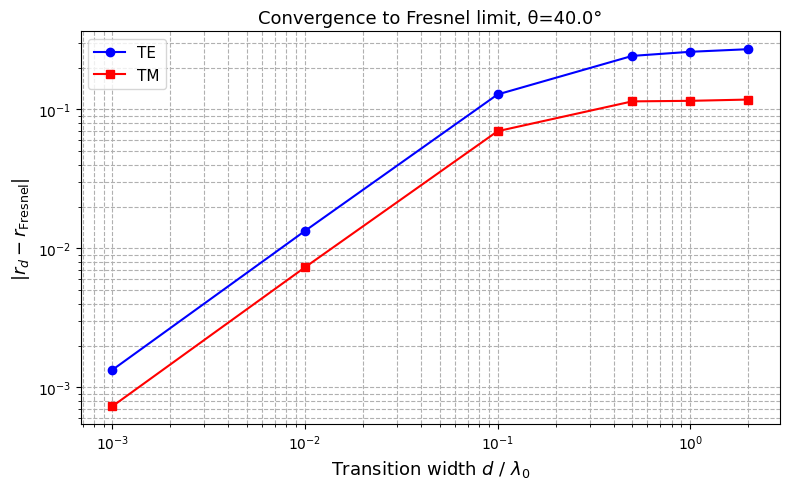

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(widths, err_te, 'bo-', ms=6, label='TE')
ax.loglog(widths, err_tm, 'rs-', ms=6, label='TM')
ax.set_xlabel('Transition width $d$ / $\\lambda_0$', fontsize=13)
ax.set_ylabel('$|r_d - r_\\mathrm{Fresnel}|$', fontsize=13)
ax.set_title(f'Convergence to Fresnel limit, θ={theta_test}°', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig('test5_fresnel_limit.png', dpi=120)
plt.show()

## Test 6 — Smooth Tanh Profile

More physically realistic: $\varepsilon_r(z) = \tfrac{\varepsilon_1+\varepsilon_2}{2} + \tfrac{\varepsilon_2-\varepsilon_1}{2}\,\tanh\!\left(\frac{z - z_c}{\delta}\right)$  
where $z_c = (z_1+z_2)/2$ and $\delta = (z_2-z_1)/6$.

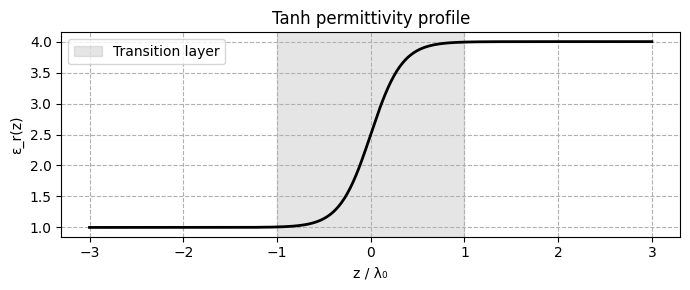

HelmholtzSolver1D: pol=S, θ=0°, λ₀=1.0, ε₁=1.007+0j, ε₂=3.993+0j, kz1=6.306+0j, kz2=12.55+0j
  → ODE res_trans=99.91/λ₀ → n_trans=200
[ODE/Dopri5] r = 0.0015∠-2.3°, t = 0.7087∠-19.9°
Energy check: R=0.000002, T=0.999998, R+T=1.000000
θ=  0° S: |r|=0.0015  R+T=1.000000
HelmholtzSolver1D: pol=P, θ=0°, λ₀=1.0, ε₁=1.007+0j, ε₂=3.993+0j, kz1=6.306+0j, kz2=12.55+0j
  → ODE res_trans=99.91/λ₀ → n_trans=200
[ODE/Dopri5] r = 0.0015∠177.7°, t = 1.4109∠-19.9°
Energy check: R=0.000002, T=0.999998, R+T=1.000000
θ=  0° P: |r|=0.0015  R+T=1.000000
HelmholtzSolver1D: pol=S, θ=30°, λ₀=1.0, ε₁=1.007+0j, ε₂=3.993+0j, kz1=5.462+0j, kz2=12.15+0j
  → ODE res_trans=99.91/λ₀ → n_trans=200
[ODE/Dopri5] r = 0.0046∠61.0°, t = 0.6704∠47.2°
Energy check: R=0.000022, T=0.999978, R+T=1.000000
θ= 30° S: |r|=0.0046  R+T=1.000000
HelmholtzSolver1D: pol=P, θ=30°, λ₀=1.0, ε₁=1.007+0j, ε₂=3.993+0j, kz1=5.462+0j, kz2=12.15+0j
  → ODE res_trans=99.91/λ₀ → n_trans=200
[ODE/Dopri5] r = 0.0028∠-146.8°, t = 1.3346∠46.9°
Energy 

In [10]:
z1t, z2t = -1.0, 1.0
zc    = 0.5 * (z1t + z2t)
delta = (z2t - z1t) / 6.0
eps1t, eps2t = 1.0, 4.0

def eps_tanh(z):
    return 0.5*(eps1t + eps2t) + 0.5*(eps2t - eps1t)*np.tanh((z - zc) / delta)

# Show profile
z_show = np.linspace(z1t - 2, z2t + 2, 400)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(z_show, [eps_tanh(z) for z in z_show], 'k-', lw=2)
ax.axvspan(z1t, z2t, color='gray', alpha=0.2, label='Transition layer')
ax.set_xlabel('z / λ₀'); ax.set_ylabel('ε_r(z)')
ax.set_title('Tanh permittivity profile'); ax.legend(); ax.grid(True, ls='--')
plt.tight_layout(); plt.show()

# Auto: res_trans = 10×max|ε|≈40/λ₀; width=2λ₀ → n_trans≈80
for th in [0, 30, 45, 60]:
    for pol in ['S', 'P']:
        sv = HelmholtzSolver1D(eps_tanh, z1t, z2t, theta_deg=th, pol=pol, lambda0=lambda0)
        ro = sv.solve_ode()
        rc = sv.energy_check(ro['r'], ro['t'])
        print(f"θ={th:3d}° {pol}: |r|={abs(ro['r']):.4f}  R+T={rc:.6f}")

HelmholtzSolver1D: pol=S, θ=45.0°, λ₀=1.0, ε₁=1.007+0j, ε₂=3.993+0j, kz1=4.459+0j, kz2=11.74+0j
  → ODE res_trans=99.91/λ₀ → n_trans=200
[ODE/Dopri5] r = 0.0093∠155.2°, t = 0.6164∠121.6°
  → FEM res_trans=199.81/λ₀ → n_trans=400,  res_ext=99.91/λ₀ → n_ext=200
[FEM] r = 0.0093∠155.3°, t = 0.6164∠121.6°


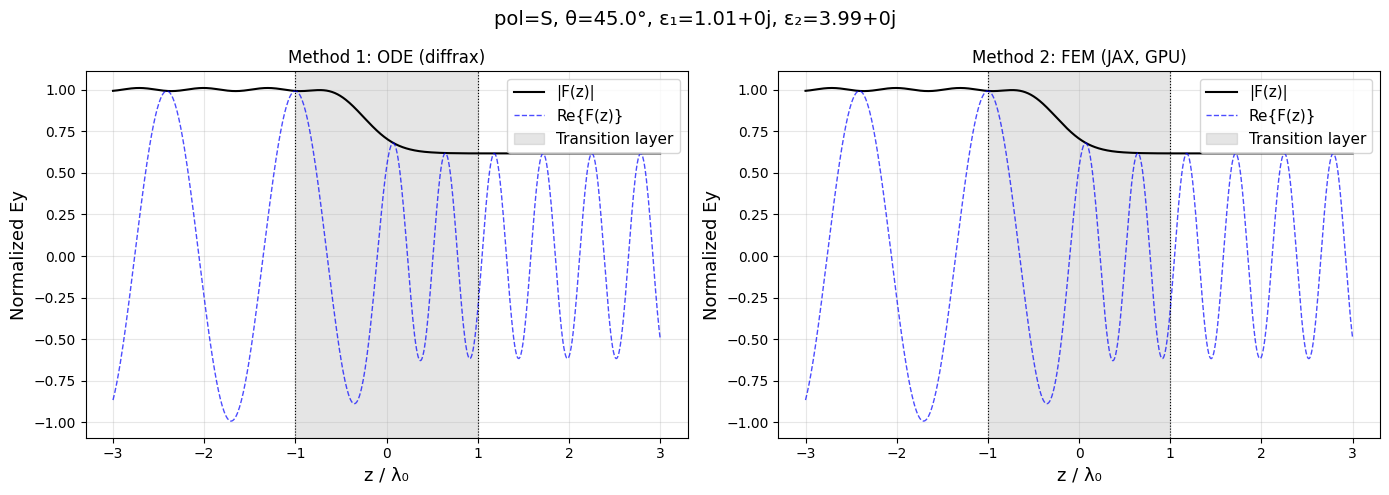

In [9]:
sv6 = HelmholtzSolver1D(eps_tanh, z1t, z2t, theta_deg=45.0, pol='S', lambda0=lambda0)
res6_ode = sv6.solve_ode()
res6_fem = sv6.solve_fem()
sv6.plot_comparison(res6_ode, res6_fem)

## Test 6 (cont.) — Field Profile Sweep over Tanh Width δ

**Generic batch pattern** (`sweep_field_ode`):
1. Build `eps_re_batch` of shape $(N_\delta, N_\mathrm{interp})$ — one row per parameter value.
2. Call `sweep_field_ode(...) → F_\mathrm{batch}` of shape $(N_\delta, n_\mathrm{trans})$, all δ in parallel via `vmap`.
3. Plot $|F(z)|$ for each row.

Transition layer fixed to $[z_1, z_2] = [-4\lambda_0, +4\lambda_0]$; δ swept from $0.05\lambda_0$ to $\lambda_0$.

Field sweep: res_trans=40/λ₀ → n_trans=320
kz1=4.443+0j,  kz2=11.75+0j
Running vmapped δ sweep (return_field=True)...
Done.


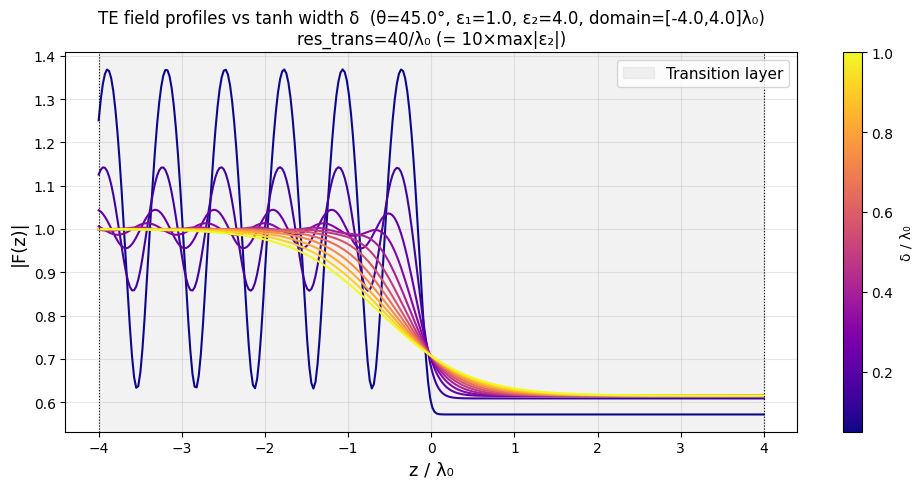

In [16]:
# ── Fixed domain and physical parameters ────────────────────────────────────
Z1_d, Z2_d   = -4.0, 4.0    # transition layer (λ₀ units)
zc_d         = 0.0           # tanh centre
eps1_d, eps2_d = 1.0, 4.0
theta_d, pol_d = 45.0, 'S'
N_INTERP = 10000
# res_trans default = 10×max|ε|≈40/λ₀; width=8λ₀ → n_trans≈320
_RES_D  = 10.0 * eps2_d
N_TRANS = max(10, int(np.ceil(_RES_D * (Z2_d - Z1_d) / lambda0)))   # = 320
print(f"Field sweep: res_trans={_RES_D:.0f}/λ₀ → n_trans={N_TRANS}")

# δ values to sweep
deltas = jnp.array(np.linspace(0.05, 1.0, 12))
N_d    = len(deltas)

# ── k-vectors (fixed for all δ) ──────────────────────────────────────────────
k0_d  = 2.0 * np.pi / lambda0
kx_d  = float(np.real(k0_d * np.sqrt(eps1_d) * np.sin(np.deg2rad(theta_d))))
kz1_d = make_kz(eps1_d, kx_d, k0_d)
kz2_d = make_kz(eps2_d, kx_d, k0_d)
print(f"kz1={kz1_d:.4g},  kz2={kz2_d:.4g}", flush=True)

# ── Build ε batch arrays (N_delta, N_INTERP) — one row per δ ────────────────
eps_re_b, eps_im_b, deps_re_b, deps_im_b = [], [], [], []
z_grid_d = None
for delta_val in deltas:
    d = float(delta_val)
    def ep(z, _d=d):
        return 0.5*(eps1_d+eps2_d) + 0.5*(eps2_d-eps1_d)*np.tanh((z - zc_d) / _d)
    zg, eg, deg = build_interp_arrays(ep, Z1_d, Z2_d, n=N_INTERP)
    eps_re_b.append(jnp.real(eg));   eps_im_b.append(jnp.imag(eg))
    deps_re_b.append(jnp.real(deg)); deps_im_b.append(jnp.imag(deg))
    if z_grid_d is None:
        z_grid_d = zg

eps_re_b  = jnp.stack(eps_re_b);  eps_im_b  = jnp.stack(eps_im_b)
deps_re_b = jnp.stack(deps_re_b); deps_im_b = jnp.stack(deps_im_b)

kx_arr_d  = jnp.full((N_d,), kx_d)
kz1_arr_d = jnp.full((N_d,), complex(kz1_d), dtype=jnp.complex128)
kz2_arr_d = jnp.full((N_d,), complex(kz2_d), dtype=jnp.complex128)

print("Running vmapped δ sweep (return_field=True)...", flush=True)
F_batch_d = sweep_ode(
    kx_arr_d, kz1_arr_d, kz2_arr_d,
    eps_re_b, eps_im_b, deps_re_b, deps_im_b,
    z_grid_d, float(k0_d), float(Z1_d), float(Z2_d), N_TRANS, pol_d,
    return_field=True,
)
print("Done.", flush=True)

# ── Plot |F(z)| for each δ ───────────────────────────────────────────────────
z_plot_d  = np.linspace(Z1_d, Z2_d, N_TRANS)
fig, ax   = plt.subplots(figsize=(10, 5))
cmap_d    = plt.cm.plasma
colors_d  = cmap_d(np.linspace(0, 1, N_d))

for i, (d_val, color) in enumerate(zip(deltas, colors_d)):
    ax.plot(z_plot_d, np.abs(np.array(F_batch_d[i])), color=color, lw=1.5)

ax.axvspan(Z1_d, Z2_d, color='gray', alpha=0.10, label='Transition layer')
ax.axvline(Z1_d, color='k', lw=0.8, ls=':')
ax.axvline(Z2_d, color='k', lw=0.8, ls=':')

sm_d = plt.cm.ScalarMappable(
    cmap=cmap_d, norm=plt.Normalize(float(deltas[0]), float(deltas[-1])))
sm_d.set_array([])
fig.colorbar(sm_d, ax=ax, label='δ / λ₀')

ax.set_xlabel('z / λ₀', fontsize=13)
ax.set_ylabel('|F(z)|', fontsize=13)
ax.set_title(
    f'TE field profiles vs tanh width δ  '
    f'(θ={theta_d}°, ε₁={eps1_d}, ε₂={eps2_d}, domain=[{Z1_d},{Z2_d}]λ₀)\n'
    f'res_trans={_RES_D:.0f}/λ₀ (= 10×max|ε₂|)',
    fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('test6_delta_sweep.png', dpi=120)
plt.show()